# Examen Final — Bienestar Mundial
## Nombre del estudiante: Kevin Bermúdez Arce

**Modalidad:** individual y asíncrona  
**Tiempo máximo:** 180 minutos  
Este examen evalúa su capacidad para **aplicar los fundamentos de Python, analizar datos con Pandas, tomar decisiones de procesamiento y comunicar resultados mediante visualizaciones**.

> **Importante:** las consignas indican el resultado que debe obtener, pero no siempre indican el método exacto. Parte de la evaluación consiste en seleccionar una solución apropiada con los recursos trabajados en el curso.

Complete únicamente las celdas de respuesta identificadas como `TODO`. No elimine las consignas. Ejecute el notebook de arriba hacia abajo y conserve las salidas que respalden sus respuestas.

## Evaluación mediante rúbrica de desempeño

La evaluación de este examen se realizará mediante una **rúbrica analítica**, no mediante puntajes asignados a cada ejercicio o sección.

### Escala oficial

| Nivel | Descriptor |
|---|---|
| **0 — No realizado** | No presenta evidencia evaluable o la respuesta no corresponde con lo solicitado. |
| **1 — Inicial** | Presenta un avance parcial, con errores importantes o una solución incompleta. |
| **2 — Intermedio** | Cumple lo esencial y produce resultados mayoritariamente correctos, aunque presenta errores menores o aspectos incompletos. |
| **3 — Avanzado** | Resuelve correctamente, con autonomía, coherencia, evidencia verificable y aplicación apropiada de los conceptos. |

### Criterios que se observarán

La rúbrica considera el desempeño demostrado en:

- carga y exploración del conjunto de datos;
- limpieza y tratamiento de datos faltantes;
- uso de estructuras, ciclos y condiciones;
- diseño y funcionamiento de funciones;
- cálculos y análisis respecto al promedio;
- comparación y transformación de datos con Pandas;
- construcción de rankings;
- selección y construcción de visualizaciones;
- interpretación sustentada en evidencia;
- síntesis crítica, coherencia y reproducibilidad del notebook.

> Cada criterio se valorará según el nivel de desempeño alcanzado: **0, 1, 2 o 3**. La calidad de la evidencia y el funcionamiento del código son más importantes que la cantidad de instrucciones completadas.


## Instrucciones generales

1. Guarde una copia como `Apellido_Nombre_Examen_Final.ipynb`.
2. Mantenga `bienestar_mundial_2023.csv` en la misma carpeta y **no modifique el archivo original**.
3. Use únicamente Python, Pandas y Matplotlib trabajados en el curso.
4. No use Internet, API ni fuentes externas.
5. El código debe ejecutarse de arriba hacia abajo sin errores.
6. Puede crear variables auxiliares cuando sean necesarias, siempre que conserve los nombres solicitados para los productos principales.
7. No sustituya valores faltantes por cero.
8. Las respuestas escritas deben basarse en resultados visibles del notebook.
9. Una asociación observada en los datos **no demuestra causalidad**.


### Criterio de autonomía

En las Partes 3 y 4 se valorará que seleccione **operaciones y visualizaciones apropiadas**, no que reproduzca una receta de código específica.

## 1. Carga, exploración y calidad de datos
El archivo contiene indicadores de bienestar por país y región.

### Variables principales

| Variable | Descripción para este examen |
|---|---|
| `pais` | País incluido en la muestra. |
| `region` | Región asignada al país. |
| `puntuacion_bienestar` | Puntuación numérica utilizada para comparar bienestar. |
| `pib_per_capita` | Indicador cuantitativo asociado al PIB per cápita en la escala suministrada por el conjunto de datos. No debe interpretarse como un monto directo en dólares. |

### 1.1 Carga y exploración
1. Importe Pandas.
2. Cargue `bienestar_mundial_2023.csv` en un DataFrame llamado `df`.
3. Muestre los primeros 10 registros.
4. Explore la estructura y calidad del conjunto de datos de manera suficiente para identificar:
   - dimensiones;
   - tipos de datos;
   - valores faltantes;
   - distribución de registros por región.

**Debe dejar visibles las salidas que utilizó para realizar esta exploración.**

In [44]:
# TODO CÓDIGO 1.1
# Cargue el archivo en df y realice la exploración solicitada.
import pandas as pd
df = pd.read_csv("bienestar_mundial_2023.csv")

print("Primeros 10 registros:")
print(df.head(10))

print("\nDimensiones del DataFrame:")
print(df.shape)

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores faltantes:")
print(df.isnull().sum())

print("\nDistribución de registros por región:")
print(df["region"].value_counts())



Primeros 10 registros:
         pais                      region  puntuacion_bienestar  \
0     Finland           Europa Occidental                 7.804   
1     Denmark           Europa Occidental                 7.586   
2     Germany           Europa Occidental                 6.892   
3       Spain           Europa Occidental                 6.436   
4  Costa Rica  America Latina y el Caribe                 6.609   
5     Uruguay  America Latina y el Caribe                 6.494   
6       Chile  America Latina y el Caribe                 6.334   
7      Brazil  America Latina y el Caribe                 6.125   
8     Czechia   Europa Central y Oriental                 6.845   
9   Lithuania   Europa Central y Oriental                 6.763   

   pib_per_capita  apoyo_social  esperanza_vida_saludable  libertad_decision  \
0           1.888         1.585                     0.535              0.772   
1           1.949         1.548                     0.537              0.734   

### 1.2 Decisión de limpieza
Para el análisis gráfico posterior necesitará comparar `pib_per_capita` con `puntuacion_bienestar`.

Cree un DataFrame llamado `df_limpio` que conserve únicamente los registros válidos para analizar esas dos variables, **sin modificar `df` y sin sustituir nulos por cero**.

Muestre cuántos registros tenía `df` y cuántos conserva `df_limpio`.

**TODO RESPUESTA 1.2:** En **2 o 3 oraciones**, explique qué problema de calidad encontró y por qué la decisión aplicada es apropiada para el análisis posterior.

In [45]:
# TODO CÓDIGO 1.2
# Cree df_limpio y deje visible evidencia del tamaño antes y después de la limpieza.
df_limpio = df.dropna(subset=["pib_per_capita", "puntuacion_bienestar"])

print("Registros antes de la limpieza:")
print(len(df))

print("\nRegistros después de la limpieza:")
print(len(df_limpio))




Registros antes de la limpieza:
40

Registros después de la limpieza:
38


**TODO RESPUESTA 1.2 — Decisión de limpieza**

R/ Se encontró que hay 2 valores faltantes en la variable pib_per_capita, lo cual podría tener algún inconveniente al momento de compararlo con la variable de puntuacion_bienestar. Para eso se crea el "df_limpio" para conservar los registros validos de ambas variables y que no se modifique el df original.

## 2. Python base: estructuras, ciclos y funciones

### 2.1 Lista de diccionarios, ciclo y condición

Convierta `df` en una lista de diccionarios llamada `registros`.

Sin utilizar operaciones de filtrado de Pandas para resolver este apartado, recorra `registros` y determine cuántos países tienen `puntuacion_bienestar` mayor o igual que `6.0`.

**Debe utilizar un ciclo y una condición.**

**Resultado esperado:** deje visible el conteo obtenido.


In [46]:
# TODO CÓDIGO 2.1
registros = df.to_dict("records")

contador = 0
for registro in registros:
    if registro["puntuacion_bienestar"] >= 6.0:
        contador += 1
print("Países con puntuación de bienestar mayor o igual a 6.0:", contador)



Países con puntuación de bienestar mayor o igual a 6.0: 23


### 2.2 Función `resumen_region`

Implemente:

`resumen_region(registros, region)`

La función debe:

- recibir la lista de diccionarios y el nombre de una región;
- recorrer los registros mediante un `for`;
- seleccionar mediante una condición los registros correspondientes;
- calcular la cantidad de países y el promedio de `puntuacion_bienestar`;
- devolver un diccionario con las claves:
  - `region`
  - `cantidad_paises`
  - `promedio_bienestar`
- devolver `None` cuando la región no exista;
- funcionar **sin depender de `df` global**.


In [47]:
# TODO CÓDIGO 2.2
def resumen_region(registros, region):
    cantidad_paises = 0
    suma_bienestar = 0
    
    for registro in registros:
        if registro["region"] == region:
            cantidad_paises += 1
            suma_bienestar += registro["puntuacion_bienestar"]
    
    if cantidad_paises == 0:
        return None
    
    promedio_bienestar = suma_bienestar / cantidad_paises
    
    return {
        "region": region,
        "cantidad_paises": cantidad_paises,
        "promedio_bienestar": promedio_bienestar
    }
    




### 2.3 Pruebas de la función

Pruebe `resumen_region()` con:

1. una región existente;
2. una región inexistente.

**Resultado esperado:** deben quedar visibles ambas pruebas de la función.


In [48]:
# TODO CÓDIGO 2.3
resultado = resumen_region(registros, "Europa Occidental")
print(resultado)

resultado = resumen_region(registros, "inexistente")
print(resultado)

{'region': 'Europa Occidental', 'cantidad_paises': 4, 'promedio_bienestar': 7.1795}
None


### 2.4 Validación de la función

En **1 o 2 oraciones**, explique qué demuestra la prueba con una región inexistente y por qué el resultado obtenido es coherente con el contrato de la función.


**TODO RESPUESTA 2.4 — Validación de la función**

R/ La prueba para una región inexistente la función la procesa correctamente y devuelve "None" como respuesta cuando se procesa pero no encuentra información.


## 3. Análisis integrado con Pandas

En esta sección se evalúa no solo la sintaxis, sino su capacidad para **decidir cómo analizar los datos**.

### 3.1 Pregunta de análisis

Seleccione **dos regiones válidas** del conjunto de datos y guárdelas en una lista llamada `regiones_comparadas`.

Formule una pregunta comparativa que pueda responder utilizando `puntuacion_bienestar`.

Indique las dos regiones seleccionadas y escriba su pregunta en 1 o 2 oraciones.


**TODO RESPUESTA 3.1 — Regiones y pregunta**

Regiones seleccionadas: Europa Occidental y América Latina y el Caribe.
Pregunta: ¿Qué región presenta un mayor promedio de puntuacion_bienestar: Europa Occidental o América Latina y el Caribe?




In [49]:
#se agrega esta sección para poder crear la lista
regiones_comparadas = ["Europa Occidental", "America Latina y el Caribe"]

### 3.2 Promedio general y diferencia respecto al promedio

- Calcule el promedio general de `puntuacion_bienestar` y guárdelo en `promedio_muestra`.
- Calcule, para cada país, la diferencia entre su puntuación y ese promedio, y guarde el resultado en `diferencia_promedio`.
- No modifique `df` para realizar este cálculo.

Muestre evidencia suficiente para identificar países por encima y por debajo del promedio.


In [50]:
# TODO CÓDIGO 3.2

promedio_muestra = df["puntuacion_bienestar"].mean()
diferencia_promedio = df["puntuacion_bienestar"] - promedio_muestra
por_encima = df.loc[diferencia_promedio > 0, ["pais", "puntuacion_bienestar"]]
por_debajo = df.loc[diferencia_promedio < 0, ["pais", "puntuacion_bienestar"]]


print("Promedio general:", promedio_muestra)
print("\nDiferencia respecto al promedio:")
print(diferencia_promedio)

print("\nPaíses por encima del promedio:")
print(por_encima)

print("\nPaíses por debajo del promedio:")
print(por_debajo)

Promedio general: 6.043425

Diferencia respecto al promedio:
0     1.760575
1     1.542575
2     0.848575
3     0.392575
4     0.565575
5     0.450575
6     0.290575
7     0.081575
8     0.801575
9     0.719575
10    0.545575
11    0.216575
12    1.079575
13    1.051575
14    0.917575
15    0.850575
16    0.085575
17   -0.225425
18   -0.203425
19   -0.092425
20    0.543575
21   -0.031425
22   -0.200425
23   -0.280425
24   -0.683425
25   -1.488425
26   -1.601425
27   -2.007425
28    1.429575
29    0.419575
30   -1.140425
31   -1.873425
32   -0.141425
33   -0.768425
34   -1.556425
35   -1.438425
36    0.100575
37   -0.029425
38   -0.218425
39   -0.713425
Name: puntuacion_bienestar, dtype: float64

Países por encima del promedio:
             pais  puntuacion_bienestar
0         Finland                 7.804
1         Denmark                 7.586
2         Germany                 6.892
3           Spain                 6.436
4      Costa Rica                 6.609
5         Uruguay      

### 3.3 Comparación regional

Construya:

- `df_comparacion`: registros correspondientes **únicamente** a las dos regiones seleccionadas;
- `resumen_por_region`: una tabla que permita comparar, para cada una de esas regiones:
  - cantidad de países;
  - promedio de `puntuacion_bienestar`;
- `df_sobre_promedio`: países de las regiones seleccionadas cuya `puntuacion_bienestar` sea mayor o igual que `promedio_muestra`.

Ordene o presente los resultados de forma que la comparación sea clara.

> Usted decide qué operaciones de Pandas son apropiadas. Se calificará la corrección del procedimiento y del resultado.


In [51]:
# TODO CÓDIGO 3.3
df_comparacion = df[df["region"].isin(regiones_comparadas)]


resumen_por_region = df_comparacion.groupby("region").agg(
    cantidad_paises=("pais", "count"),
    promedio_bienestar=("puntuacion_bienestar", "mean")
).reset_index()


df_sobre_promedio = df_comparacion[
    df_comparacion["puntuacion_bienestar"] >= promedio_muestra
]


print("Registros de las regiones seleccionadas:")
print(df_comparacion)

print("Resumen por región:")
print(resumen_por_region)

print("Países de las regiones seleccionadas con puntuación mayor o igual al promedio general:")
print(df_sobre_promedio)



Registros de las regiones seleccionadas:
         pais                      region  puntuacion_bienestar  \
0     Finland           Europa Occidental                 7.804   
1     Denmark           Europa Occidental                 7.586   
2     Germany           Europa Occidental                 6.892   
3       Spain           Europa Occidental                 6.436   
4  Costa Rica  America Latina y el Caribe                 6.609   
5     Uruguay  America Latina y el Caribe                 6.494   
6       Chile  America Latina y el Caribe                 6.334   
7      Brazil  America Latina y el Caribe                 6.125   

   pib_per_capita  apoyo_social  esperanza_vida_saludable  libertad_decision  \
0           1.888         1.585                     0.535              0.772   
1           1.949         1.548                     0.537              0.734   
2           1.919         1.401                     0.539              0.618   
3           1.798         1.491    

### 3.4 Ranking global

Cree `top_5` con los **cinco países de mayor `puntuacion_bienestar`**, ordenados de mayor a menor.

Conserve al menos:

- `pais`
- `puntuacion_bienestar`


In [52]:
# TODO CÓDIGO 3.4
top_5 = df.nlargest(5, "puntuacion_bienestar")[["pais", "puntuacion_bienestar"]]

print("Top 5 países con mayor puntuación de bienestar:")
print(top_5)




Top 5 países con mayor puntuación de bienestar:
           pais  puntuacion_bienestar
0       Finland                 7.804
1       Denmark                 7.586
28       Israel                 7.473
12  New Zealand                 7.123
13    Australia                 7.095


### 3.5 Respuesta analítica

Responda la pregunta formulada en 3.1 utilizando **al menos dos cifras verificables** obtenidas en las salidas de esta sección.


**TODO RESPUESTA 3.5 — Análisis**

R/ Según el analisis realizado Europa Occidental presenta un mayor promedio de puntuación de bienestar que América Latina y el Caribe. Según lo que nos mostró el "resumen_por_region", Europa Occidental obtuvo un promedio de 7.1795, mientras que América Latina y el Caribe obtuvo 6.3905. Esto permite confirmar que Europa Occidental presenta 0.789 promedio superior por puntos aproximadamente.


## 4. Visualización e interpretación

Se evaluará la selección de una representación apropiada, la claridad del gráfico y la interpretación basada en evidencia.

### 4.1 Ranking de los cinco países

Represente visualmente `top_5` de manera que sea fácil comparar los cinco países.

El gráfico debe incluir:

- título;
- nombres o etiquetas necesarias;
- presentación legible;
- orden coherente con el ranking.

**Usted decide el tipo de gráfico apropiado.**


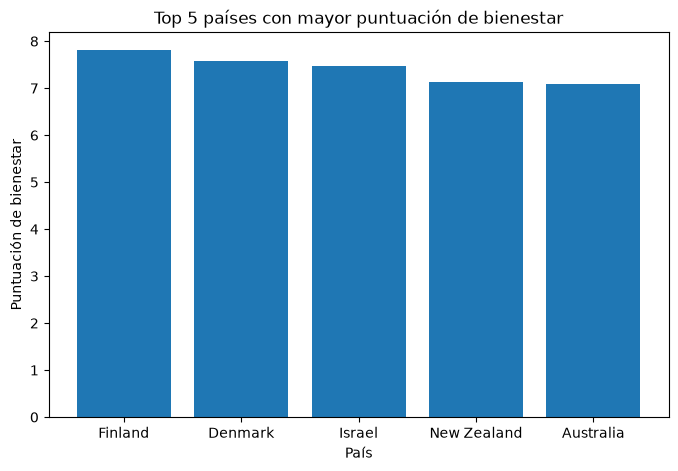

In [53]:
# TODO CÓDIGO 4.1
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(top_5["pais"], top_5["puntuacion_bienestar"])
plt.title("Top 5 países con mayor puntuación de bienestar")
plt.xlabel("País")
plt.ylabel("Puntuación de bienestar")
plt.show()

### 4.2 Relación entre dos variables cuantitativas

Utilizando **`df_limpio`**, construya una visualización apropiada para explorar la relación entre:

- `pib_per_capita`
- `puntuacion_bienestar`

Incluya título, ejes identificados y presentación legible.

**Usted decide qué tipo de gráfico permite analizar mejor la relación entre estas dos variables cuantitativas.**


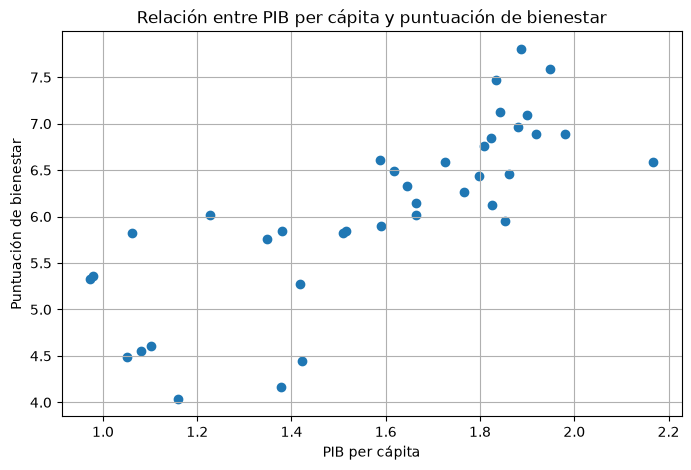

In [54]:
# TODO CÓDIGO 4.2


plt.figure(figsize=(8, 5))
plt.scatter(df_limpio["pib_per_capita"], df_limpio["puntuacion_bienestar"])
plt.title("Relación entre PIB per cápita y puntuación de bienestar")
plt.xlabel("PIB per cápita")
plt.ylabel("Puntuación de bienestar")
plt.grid(True)
plt.show()



### 4.3 Interpretación

Explique brevemente:

1. qué muestra el gráfico del ranking;
2. qué patrón o asociación observa en el segundo gráfico;
3. por qué esa asociación no permite afirmar causalidad.

Incluya al menos una cifra verificable del análisis.


**TODO RESPUESTA 4.3 — Interpretación de visualizaciones**

R/ En el gráfico del ranking podemos observar que Finlandia tiene la mayor puntuación de bienestar, seguido por los 4 países que en conjunto formarían el top 5.
En el segundo gráfico se puede confirmar una tendencia positiva, donde los países con mayor PIB per cápita tienden a presentar una mayor puntuación de bienestar. Esto no demuestra que sea necesariamente causalidad, porque el gráfico solo muestra una relación entre las variables y pueden existir otros factores que influyan, pero puede estar estrechamente relacionado.


## 5. Síntesis crítica

### 5.1 Síntesis final

Redacte una síntesis breve que contenga:

1. **dos hallazgos numéricos relevantes** obtenidos durante el examen;
2. la salida o cálculo que respalda cada hallazgo;
3. **una limitación** del conjunto de datos o del análisis realizado;
4. una conclusión expresada en términos **no causales**.

**Extensión recomendada:** 5 a 7 oraciones.

La síntesis debe integrar resultados ya obtenidos; no es necesario realizar análisis nuevos.


**TODO RESPUESTA 5.1 — Síntesis crítica**

Según el analisis realizado podemos observar que el promedio general de puntuacion_bienestar fue de 6.043425, según el cálculo realizado en la sección 3.2. Además, Finlandia obtuvo la mayor puntuación de bienestar con 7.804, según el ranking top_5 de la sección 3.4. La comparación regional mostró que Europa Occidental tuvo un promedio de 7.1795, mientras que América Latina y el Caribe obtuvo 6.3905. El análisis también mostró una tendencia positiva entre el PIB per cápita y la puntuación de bienestar, aunque existen diferencias entre los países. Una limitación es que el conjunto de datos contiene algunos valores faltantes, como el PIB per cápita de Brasil, lo que puede afectar algunos análisis. En conclusión, los datos muestran una asociación entre un mayor PIB per cápita y una mayor puntuación de bienestar, pero no permiten afirmar que una variable cause directamente la otra.


## Lista de comprobación antes de entregar

- [ ] El archivo está nombrado `Apellido_Nombre_Examen_Final.ipynb`.
- [ ] El notebook ejecuta de arriba hacia abajo sin errores.
- [ ] `bienestar_mundial_2023.csv` no fue modificado.
- [ ] `df` conserva los datos originales cargados.
- [ ] `df_limpio` se usa para el análisis de `pib_per_capita`.
- [ ] La función `resumen_region` funciona para una región válida y una inexistente.
- [ ] La Parte 3 contiene resultados visibles que respaldan la comparación.
- [ ] `top_5` contiene cinco países ordenados de mayor a menor bienestar.
- [ ] Los dos gráficos son legibles y están identificados.
- [ ] Las respuestas escritas citan evidencia numérica obtenida en el notebook.
- [ ] La conclusión evita afirmaciones causales no sustentadas.
- [ ] Las salidas visibles permiten valorar los criterios de la rúbrica de desempeño.
- [ ] Las respuestas muestran evidencia suficiente para determinar el nivel alcanzado (0–3).
